In [33]:
import py_ttcross as ttc
from py_ttcross.quantic_tt_cross.interpolators_1D import (
    greedy_one_dim_func_interpolator,
    ttrc_one_dim_func_interpolator,
)
import numpy as np
import numba
import matplotlib.pyplot as plt

In [86]:
def func(x):
    return np.sin(x)


def func2(x):
    B = 2 ** (-30)
    return np.cos(x / B) * np.cos(x / (4 * np.sqrt(5) * B)) * np.exp(-(x**2)) + 2 * np.exp(-x)

In [117]:
interval = [0, 2e-30]
d = 8

test_interpolator = greedy_one_dim_func_interpolator(
    func=func2,
    interval=interval,
    d=d,
    complex_function=False,
    max_bond=5,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

In [118]:
test_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.0006642341613769531 seconds and 1 tries.
Sweep 1


In [119]:
for tens in test_interpolator.mps:
    print(tens.shape)

(2, 1)
(1, 2, 1)
(1, 2, 1)
(1, 2, 1)
(1, 2, 1)
(1, 2, 1)
(1, 2, 1)
(1, 2)


<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/rg/ttf3h2zn7yb9z54k911xl58c0000gn/T/ipykernel_19208/3486540808.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


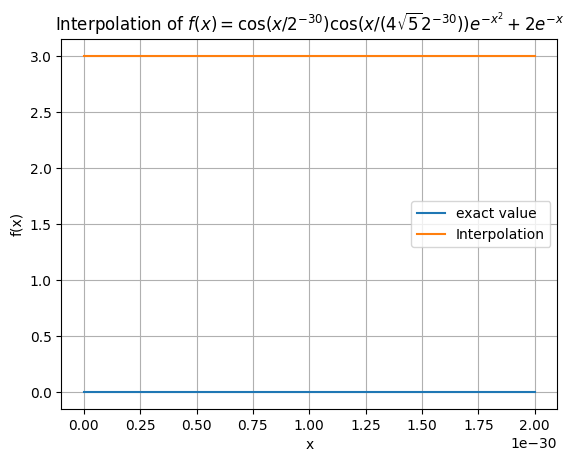

In [120]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([test_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
mps = test_interpolator.interpolation

new_interpolator = greedy_one_dim_func_interpolator.load_mps(mps, interval, complex_func=False)

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/rg/ttf3h2zn7yb9z54k911xl58c0000gn/T/ipykernel_19208/2484605887.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


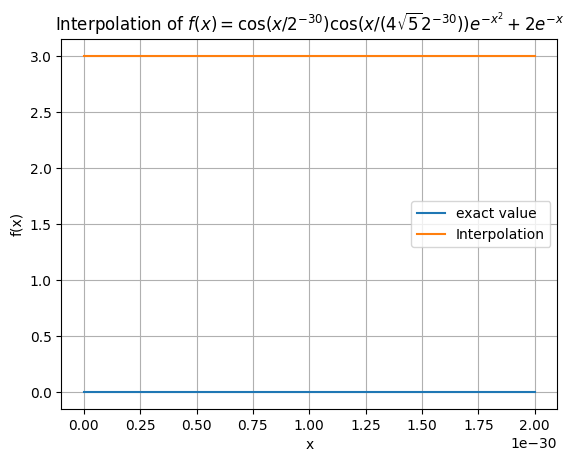

In [122]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([new_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()

In [123]:
from py_ttcross.pdes.als import *

In [124]:
prolong_als = ProlongationALS(mps, 10, 12, 1e-10, 20)
prolong_als.optimize()

(array([array([[-0.7076255 +0.0e+000j,  0.70658768+0.0e+000j],
               [-0.70658768+8.4e-323j, -0.7076255 +8.9e-323j]]),
        array([[[-7.07582349e-01-8.4e-323j,  7.77472324e-03+2.0e-323j],
                [-7.06372367e-01-9.4e-323j, -7.80333404e-03-2.5e-323j]],
 
               [[-5.19262696e-04-4.4e-323j,  5.70551789e-06+0.0e+000j],
                [ 6.92496351e-04-4.4e-323j, -1.55952326e-02-4.4e-323j]]]),
        array([[[-7.07732461e-01+0.0000e+000j,  5.45584870e-03-1.5810e-322j],
                [-7.06438084e-01+4.9407e-324j, -5.49817905e-03+1.6798e-322j]],
 
               [[-5.49711310e-02+0.0000e+000j,  4.23767723e-04-9.8813e-324j],
                [ 6.28309146e-02-1.4822e-323j, -9.96509042e-01+3.2524e-320j]]]),
        array([[[-7.07762329e-01+0.0000e+000j,  3.79721081e-03+4.9407e-324j],
                [-7.06429888e-01+1.4328e-322j, -3.85730814e-03+1.9763e-323j]],
 
               [[-8.36323666e-02+0.0000e+000j,  4.48695435e-04+9.8813e-324j],
                [ 8.921

In [125]:
new_interpolator = greedy_one_dim_func_interpolator.load_mps(prolong_als.fine_mps, interval, complex_func=False)

In [109]:
[tens.shape for tens in prolong_als.fine_mps]

[(2, 2),
 (2, 2, 3),
 (3, 2, 3),
 (3, 2, 3),
 (3, 2, 3),
 (3, 2, 3),
 (3, 2, 3),
 (3, 2, 2),
 (2, 2)]

In [110]:
new_interpolator.eval(1)

array(0.05166448-3.56e-322j)

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/rg/ttf3h2zn7yb9z54k911xl58c0000gn/T/ipykernel_19208/4020904535.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


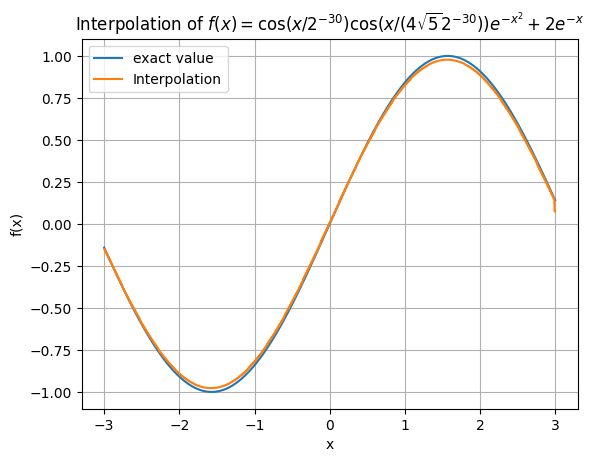

In [112]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([16 * new_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()